Файлов в датасете: 113
Загрузка завершена.
Субъектов обработано: 113
  БП (label=1): 75
  Норма (label=0): 38
  Уникальных субъектов: 113
Итоговый датасет: 113 субъектов × 32 признаков
  БП  (label=1): 75
  Норма (label=0): 38

Nested GroupKFold:
  Fold 1: ACC=0.870, BACC=0.812, F1=0.909, AUC=0.992, best_params={'rf__max_depth': None, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 1, 'rf__n_estimators': 200}
  Fold 2: ACC=0.957, BACC=0.938, F1=0.968, AUC=0.975, best_params={'rf__max_depth': None, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 4, 'rf__n_estimators': 200}
  Fold 3: ACC=0.913, BACC=0.875, F1=0.938, AUC=0.917, best_params={'rf__max_depth': None, 'rf__max_features': 0.5, 'rf__min_samples_leaf': 2, 'rf__n_estimators': 300}
  Fold 4: ACC=0.773, BACC=0.681, F1=0.848, AUC=0.943, best_params={'rf__max_depth': None, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 4, 'rf__n_estimators': 500}
  Fold 5: ACC=0.864, BACC=0.824, F1=0.903, AUC=0.952, best_params={'rf__max_

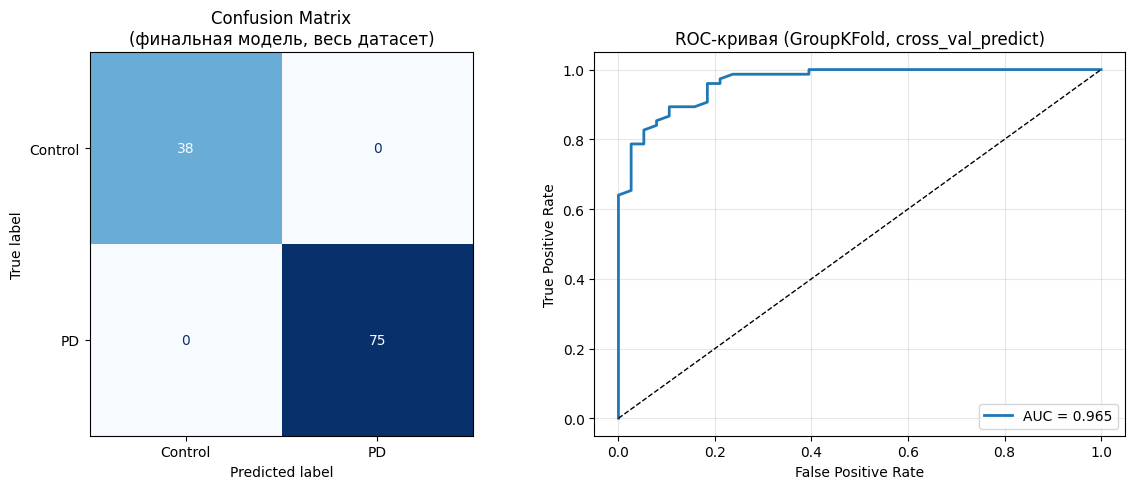

Сохранено: metrics_plots.png

МЕТРИКИ ПРИЗНАКОВ
           feature  mean_control       mean_PD      p_value significant
         sd_CoPy_R    400.246002    356.843095 2.263206e-09         ***
  mean_heel_peak_L    284.645200    196.951212 2.113921e-06         ***
ASI_mean_heel_peak     14.164860     30.547432 8.273103e-06         ***
  mean_heel_peak_R    272.795089    191.322778 1.229912e-05         ***
  kurtosis_cycle_R     11.901156     22.750154 1.463060e-05         ***
   mean_toe_peak_R    121.458322     68.139380 2.213821e-05         ***
         sd_CoPy_L    390.478548    363.542352 4.244578e-05         ***
     sd_toe_peak_L     35.147768     23.007799 6.617629e-05         ***
   mean_toe_peak_L    111.608309     68.674695 3.205437e-04         ***
       CV_stride_R   1314.618755    802.800764 4.657761e-04         ***
        CV_swing_R   1046.919490    709.541136 7.803326e-04         ***
     sd_toe_peak_R     33.436986     23.060495 8.902003e-04         ***
    sd_heel_peak

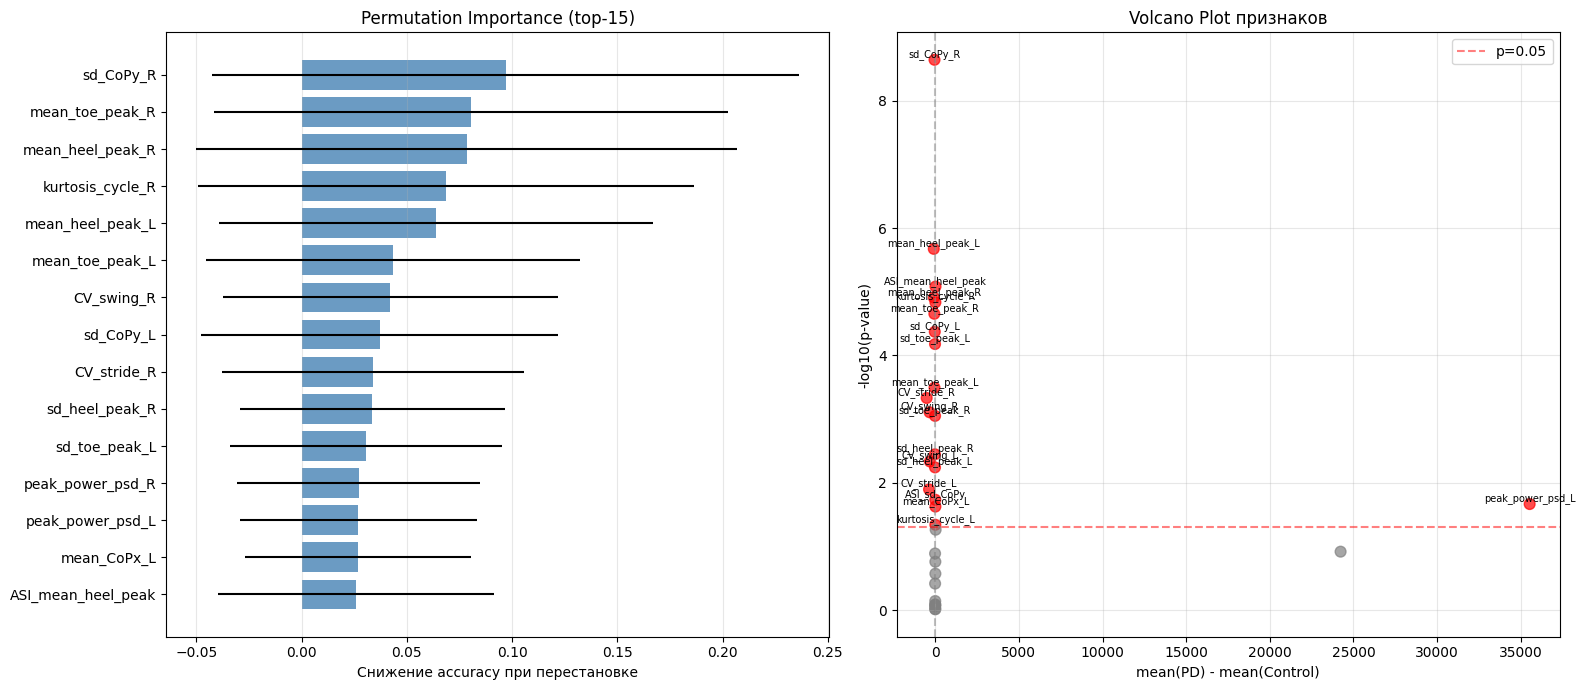

Сохранено: feature_analysis.png


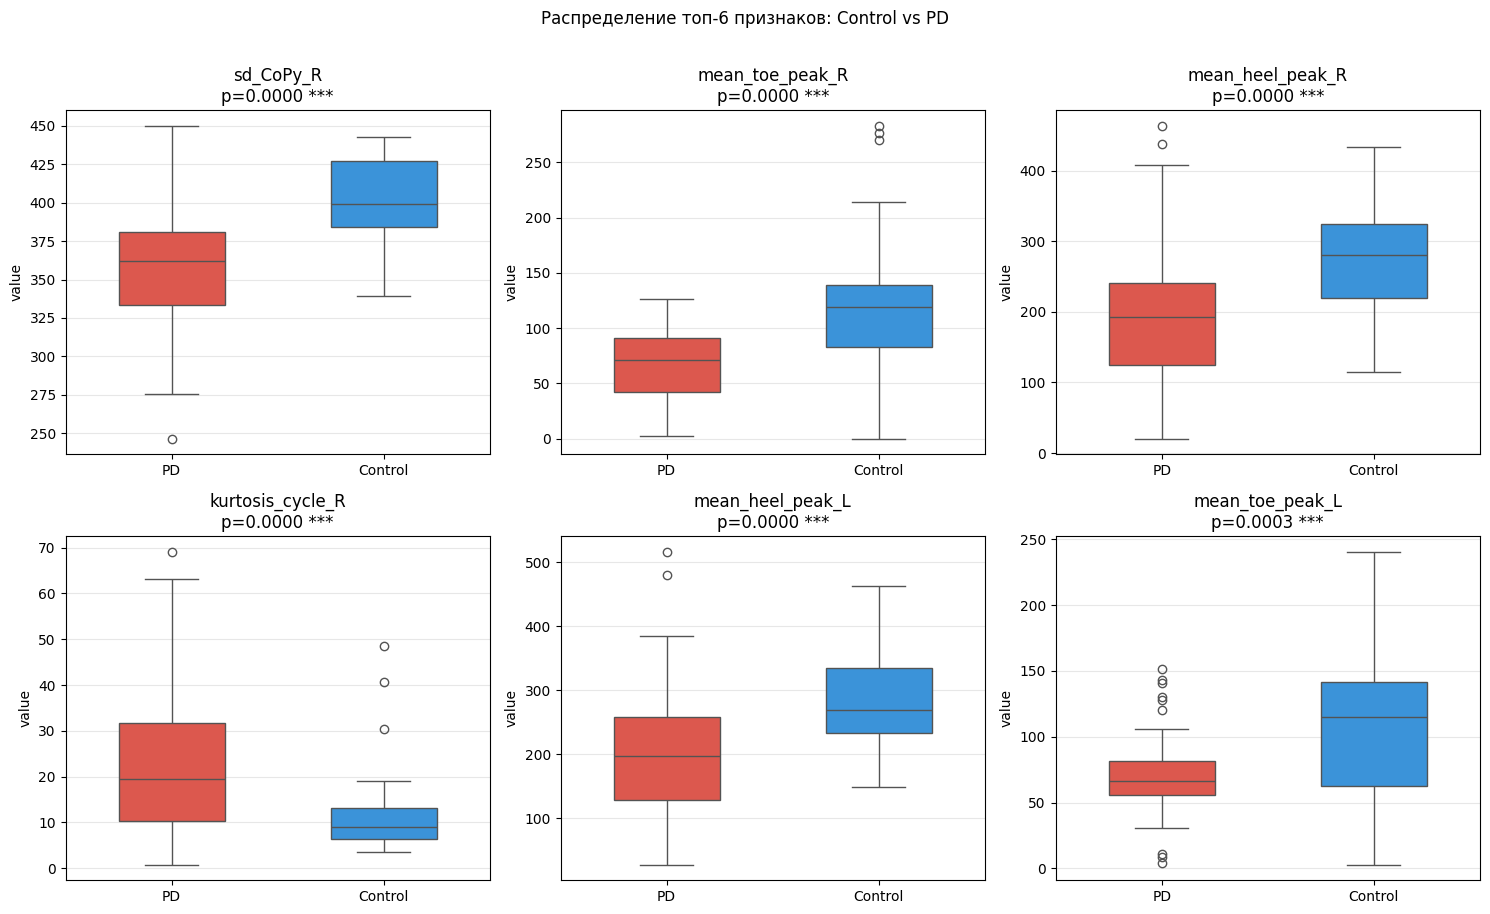

Сохранено: feature_boxplots.png

✓ subject_features.csv       — матрица признаков всех субъектов (после фильтрации)
✓ feature_stats.csv          — t-тест и статистика по каждому признаку
✓ permutation_importance.csv — важность признаков
✓ metrics_plots.png          — confusion matrix + ROC
✓ feature_analysis.png       — importance + volcano plot
✓ feature_boxplots.png       — boxplots топ-6 признаков

Отобрано признаков: 26 из 32

МЕТРИКИ с отобранными признаками (GroupKFold):
  Accuracy   0.8933 ± 0.0366
  F1         0.9253 ± 0.0243
  ROC-AUC    0.9626 ± 0.0348


In [ ]:
# ============================================================
#  GaitPDB — RF Classification (Alam et al. 2017, extended)
#  Запустить в Google Colab
# ============================================================

# ── 0. Установка зависимостей ────────────────────────────────
# !pip install -q wget  # уже есть в Colab

# ── 1. Импорты ──────────────────────────────────────────────
import os
import re
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from scipy.signal import welch, butter, filtfilt
from scipy.stats import skew, kurtosis, ttest_ind

from sklearn.model_selection import (
    GroupKFold, GridSearchCV, cross_validate, cross_val_predict
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_curve, balanced_accuracy_score
)
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance

# ── 2. Скачивание датасета ───────────────────────────────────
BASE_URL = "https://physionet.org/files/gaitpdb/1.0.0/"
DATA_DIR = "gaitpdb"
os.makedirs(DATA_DIR, exist_ok=True)


def download_file(url, dest):
    if not os.path.exists(dest):
        urllib.request.urlretrieve(url, dest)


# Скачиваем список файлов
index_url = BASE_URL + "SHA256SUMS.txt"
sha_path = os.path.join(DATA_DIR, "SHA256SUMS.txt")
download_file(index_url, sha_path)

with open(sha_path) as f:
    lines = f.readlines()

# Правильный паттерн для файлов данных
data_files = [
    l.split()[-1]
    for l in lines
    if len(l.split()) == 2
    and l.split()[-1].endswith(".txt")
    and l.split()[-1][0] in ("G", "C")
]

print(f"Файлов в датасете: {len(data_files)}")

for fname in data_files:
    dest = os.path.join(DATA_DIR, fname)
    download_file(BASE_URL + fname, dest)

print("Загрузка завершена.")

# ── 3. Константы ─────────────────────────────────────────────
FS = 100           # Гц
THRESHOLD_N = 20.0 # Н — порог stance/swing
SKIP_SECONDS = 20  # с — убрать начало
MIN_STRIDES = 5    # минимум циклов для субъекта

# Координаты датчиков (мм) из format.txt physionet
# Порядок: S1..S8, L — левая нога
SENSOR_COORDS_L = np.array([
    [-500, -800], [-700, -400], [-300, -400], [-700,   0],
    [-300,    0], [-700,  400], [-300,  400], [-500, 800]
], dtype=float)
SENSOR_COORDS_R = SENSOR_COORDS_L * np.array([-1, 1])  # зеркало по x

# ── 4. Вспомогательные функции ───────────────────────────────
def lp_filter(sig, cutoff=20, fs=FS, order=4):
    """Butterworth low-pass."""
    b, a = butter(order, cutoff / (fs / 2), "low")
    return filtfilt(b, a, sig)


def segment_strides(total_force):
    """Возвращает список (HS_start, TO_end) индексов каждого stance."""
    binary = (total_force > THRESHOLD_N).astype(np.int8)
    diff = np.diff(binary)
    starts = (np.where(diff == 1)[0] + 1).tolist()
    ends = (np.where(diff == -1)[0] + 1).tolist()
    if not starts or not ends:
        return []
    if ends[0] < starts[0]:
        ends = ends[1:]
    n = min(len(starts), len(ends))
    return list(zip(starts[:n], ends[:n]))


def compute_cop(sensors_8, coords_xy):
    """CoP (x, y) для кадров, где нога на земле."""
    total = sensors_8.sum(axis=1, keepdims=True).clip(min=1e-6)
    cop_x = (sensors_8 * coords_xy[:, 0]).sum(axis=1) / total.squeeze()
    cop_y = (sensors_8 * coords_xy[:, 1]).sum(axis=1) / total.squeeze()
    return cop_x, cop_y


def asymmetry_index(x_l, x_r):
    """ASI = |L-R| / (0.5*(L+R)) * 100"""
    denom = 0.5 * (abs(x_l) + abs(x_r))
    return abs(x_l - x_r) / (denom + 1e-9) * 100

# ── 5. Извлечение признаков одной ноги ───────────────────────
def extract_one_side(sensors_8, total, coords):
    """
    Alam et al. 2017 — 13 признаков для одной ноги.
    sensors_8: (N, 8), total: (N,), coords: (8,2)
    """
    sensors_8 = sensors_8.copy()
    total = total.copy()
    sensors_8[sensors_8 < THRESHOLD_N] = 0.0
    total[total < THRESHOLD_N] = 0.0

    strides = segment_strides(total)
    if len(strides) < MIN_STRIDES:
        return None

    swing_times, stride_times, cycle_dur = [], [], []
    heel_peaks, toe_peaks = [], []

    for i in range(len(strides) - 1):
        s0, s1 = strides[i]
        n0, _ = strides[i + 1]

        stance_dur = (s1 - s0) / FS
        swing_dur = (n0 - s1) / FS
        stride_dur = stance_dur + swing_dur

        if swing_dur <= 0 or stride_dur <= 0:
            continue

        swing_times.append(swing_dur)
        stride_times.append(stride_dur)
        cycle_dur.append(stride_dur)

        # Пиковые силы: первые/последние 5 отсчётов стойки
        heel_win = sensors_8[s0: s0 + 5, [0]]           # датчик S1 — пятка
        toe_win = sensors_8[max(s1 - 5, s0): s1, [7]]   # датчик S8 — носок
        heel_peaks.append(heel_win.max() if heel_win.size else 0)
        toe_peaks.append(toe_win.max() if toe_win.size else 0)

    if len(swing_times) < MIN_STRIDES:
        return None

    sw = np.array(swing_times)
    st = np.array(stride_times)
    hp = np.array(heel_peaks)
    tp = np.array(toe_peaks)
    cd = np.array(cycle_dur)

    # CoP только в stance-фазах
    stance_mask = total > THRESHOLD_N
    cop_x, cop_y = compute_cop(sensors_8[stance_mask], coords)

    # PSD
    _, psd = welch(total, fs=FS, nperseg=min(256, len(total)))

    eps = 1e-9
    feats = {
        "CV_swing":       sw.mean() / (sw.std() + eps) * 100,
        "CV_stride":      st.mean() / (st.std() + eps) * 100,
        "mean_CoPx":      np.nanmean(cop_x),
        "sd_CoPx":        np.nanstd(cop_x),
        "mean_CoPy":      np.nanmean(cop_y),
        "sd_CoPy":        np.nanstd(cop_y),
        "mean_heel_peak": hp.mean(),
        "mean_toe_peak":  tp.mean(),
        "sd_heel_peak":   hp.std(),
        "sd_toe_peak":    tp.std(),
        "kurtosis_cycle": float(kurtosis(cd)),
        "skewness_cycle": float(skew(cd)),
        "peak_power_psd": float(psd.max()),
    }
    return feats

# ── 6. Извлечение признаков обеих ног + асимметрия ───────────
FEAT_NAMES_BASE = [
    "CV_swing", "CV_stride", "mean_CoPx", "sd_CoPx",
    "mean_CoPy", "sd_CoPy", "mean_heel_peak", "mean_toe_peak",
    "sd_heel_peak", "sd_toe_peak", "kurtosis_cycle",
    "skewness_cycle", "peak_power_psd",
]

ASYM_PAIRS = [
    "CV_swing", "CV_stride", "sd_CoPx", "sd_CoPy",
    "mean_heel_peak", "mean_toe_peak",
]


def extract_subject_features(filepath):
    """Читает файл субъекта, возвращает вектор признаков или None."""
    try:
        data = np.loadtxt(filepath)
    except Exception:
        return None

    skip = int(SKIP_SECONDS * FS)
    if data.shape[0] <= skip + 100:
        return None
    data = data[skip:]

    # Столбцы согласно format.txt (0-based индексы):
    # 0:время, 1-8:L1-L8, 9-16:R1-R8, 17:Total_L, 18:Total_R
    sensors_L = data[:, 1:9]
    sensors_R = data[:, 9:17]
    total_L = data[:, 17]
    total_R = data[:, 18]

    # Низкочастотная фильтрация суммарных сигналов
    total_L = lp_filter(total_L)
    total_R = lp_filter(total_R)

    feats_L = extract_one_side(sensors_L, total_L, SENSOR_COORDS_L)
    feats_R = extract_one_side(sensors_R, total_R, SENSOR_COORDS_R)

    if feats_L is None or feats_R is None:
        return None

    row = {}
    for k in FEAT_NAMES_BASE:
        row[f"{k}_L"] = feats_L[k]
        row[f"{k}_R"] = feats_R[k]

    # Признаки асимметрии
    for k in ASYM_PAIRS:
        row[f"ASI_{k}"] = asymmetry_index(feats_L[k], feats_R[k])

    return row

# ── 7. Обход всего датасета ───────────────────────────────────
records = []
for fname in data_files:
    path = os.path.join(DATA_DIR, fname)
    label = 1 if "Pt" in fname else 0
    feats = extract_subject_features(path)
    if feats is not None:
        feats["label"] = label
        feats["subject"] = fname
        m = re.match(r"^(?:Ga|Ju|Si)(.+?)\.txt$", fname)
        feats["subject_id"] = m.group(1) if m else fname
        records.append(feats)

df = pd.DataFrame(records)
print(f"Субъектов обработано: {len(df)}")
print(f"  БП (label=1): {df.label.sum()}")
print(f"  Норма (label=0): {(df.label == 0).sum()}")
print(f"  Уникальных субъектов: {df['subject_id'].nunique()}")

# ── 8. Подготовка данных ─────────────────────────────────────
feature_cols = [
    c for c in df.columns
    if c not in ("label", "subject", "subject_id")
]

X = df[feature_cols].values.astype(float)
y = df["label"].values

# 1. Inf → NaN
X = np.where(np.isinf(X), np.nan, X)

# 2. Impute NaN → медиана столбца
col_median = np.nanmedian(X, axis=0)
nan_rows, nan_cols = np.where(np.isnan(X))
X[nan_rows, nan_cols] = col_median[nan_cols]

# 3. Удалить строки, где всё ещё NaN
valid_mask = ~np.isnan(X).any(axis=1)
X = X[valid_mask]
y = y[valid_mask]
subjects = df["subject"].values[valid_mask]
groups = df["subject_id"].values[valid_mask]

print(f"Итоговый датасет: {X.shape[0]} субъектов × {X.shape[1]} признаков")
print(f"  БП  (label=1): {(y == 1).sum()}")
print(f"  Норма (label=0): {(y == 0).sum()}")

assert len(np.unique(y)) == 2, "Только один класс!"

# Для последующего анализа признаков удобно иметь DataFrame
feat_df = pd.DataFrame(X, columns=feature_cols)
feat_df["label"] = y

# ── 10. RF-пайплайн с Nested CV ──────────────────────────────
pipe_rf = Pipeline([
    ("scaler", StandardScaler()),
    ("rf", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1,
    )),
])

param_grid_rf = {
    "rf__n_estimators":     [200, 300, 500],
    "rf__max_features":     ["sqrt", 0.4, 0.6],
    "rf__min_samples_leaf": [1, 2, 4],
    # max_depth убираем — всегда None
}

outer_cv = GroupKFold(n_splits=5)
inner_cv = GroupKFold(n_splits=4)
pipe_model = pipe_rf

accs, baccs, f1s, aucs = [], [], [], []

print("\nNested GroupKFold:")
for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y, groups), 1):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    groups_train = groups[train_idx]

    grid = GridSearchCV(
        pipe_model, param_grid,
        cv=inner_cv,
        scoring="balanced_accuracy",
        n_jobs=-1,
    )
    grid.fit(X_train, y_train, groups=groups_train)
    best = grid.best_estimator_

    y_pred = best.predict(X_test)
    y_proba = best.predict_proba(X_test)[:, 1]

    accs.append(accuracy_score(y_test, y_pred))
    baccs.append(balanced_accuracy_score(y_test, y_pred))
    f1s.append(f1_score(y_test, y_pred))
    aucs.append(roc_auc_score(y_test, y_proba))

    print(
        f"  Fold {fold}: "
        f"ACC={accs[-1]:.3f}, BACC={baccs[-1]:.3f}, "
        f"F1={f1s[-1]:.3f}, AUC={aucs[-1]:.3f}, "
        f"best_params={grid.best_params_}"
    )

print("\nИТОГОВЫЕ МЕТРИКИ (Nested GroupKFold):")
print(f"  Accuracy           {np.mean(accs):.4f} ± {np.std(accs):.4f}")
print(f"  Balanced Accuracy  {np.mean(baccs):.4f} ± {np.std(baccs):.4f}")
print(f"  F1-score           {np.mean(f1s):.4f} ± {np.std(f1s):.4f}")
print(f"  ROC-AUC            {np.mean(aucs):.4f} ± {np.std(aucs):.4f}")

# ── 11. Финальная RF-модель (GridSearchCV на всех данных) ────
print("\nПодбор гиперпараметров RF на всех данных (GroupKFold)...")
final_inner_cv = GroupKFold(n_splits=4)
final_grid = GridSearchCV(
    pipe_model,
    param_grid,
    cv=final_inner_cv,
    scoring="balanced_accuracy",
    n_jobs=-1,
)
final_grid.fit(X, y, groups=groups)
print("Лучшие параметры (full data):", final_grid.best_params_)

pipe = final_grid.best_estimator_  # финальный RF-пайплайн

# ── 12. Детальный отчёт на всем датасете ─────────────────────
pipe.fit(X, y)
y_pred = pipe.predict(X)
y_prob = pipe.predict_proba(X)[:, 1]

print("\nClassification Report (full train set — для диагностики):")
print(classification_report(y, y_pred, target_names=["Control", "PD"]))

# ── 13. Матрица ошибок и ROC-кривая ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm = confusion_matrix(y, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["Control", "PD"]).plot(
    ax=axes[0], colorbar=False, cmap="Blues"
)
axes[0].set_title("Confusion Matrix\n(финальная модель, весь датасет)")

# CV-прогнозы вероятностей с фиксированными гиперпараметрами
all_y_prob = cross_val_predict(
    pipe, X, y,
    cv=outer_cv,
    groups=groups,
    method="predict_proba",
)[:, 1]
all_y_test = y  # cross_val_predict возвращает предсказания в исходном порядке

fpr, tpr, _ = roc_curve(all_y_test, all_y_prob)
auc_val = roc_auc_score(all_y_test, all_y_prob)

axes[1].plot(fpr, tpr, lw=2, label=f"AUC = {auc_val:.3f}")
axes[1].plot([0, 1], [0, 1], "k--", lw=1)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC-кривая (GroupKFold, cross_val_predict)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("metrics_plots.png", dpi=150)
plt.show()
print("Сохранено: metrics_plots.png")

# ── 14. Метрики признаков ────────────────────────────────────
print("\n" + "=" * 55)
print("МЕТРИКИ ПРИЗНАКОВ")
print("=" * 55)

rows = []
for col in feature_cols:
    ctrl = feat_df.loc[feat_df.label == 0, col].values
    pd_ = feat_df.loc[feat_df.label == 1, col].values
    t_stat, p_val = ttest_ind(ctrl, pd_, equal_var=False)
    rows.append({
        "feature":      col,
        "mean_control": ctrl.mean(),
        "std_control":  ctrl.std(),
        "mean_PD":      pd_.mean(),
        "std_PD":       pd_.std(),
        "t_stat":       t_stat,
        "p_value":      p_val,
        "significant":  "***" if p_val < 0.001 else (
                        "**" if p_val < 0.01 else (
                        "*" if p_val < 0.05 else "ns")),
    })

feat_stats = pd.DataFrame(rows).sort_values("p_value")
print(feat_stats[[
    "feature", "mean_control", "mean_PD", "p_value", "significant"
]].to_string(index=False))

# ── 15. Permutation Importance ───────────────────────────────
# Блок Permutation Importance — заменить на:
rf_model = pipe["rf"]   # извлечь RF из pipeline
importances = rf_model.feature_importances_
std_imp     = np.std([tree.feature_importances_
                      for tree in rf_model.estimators_], axis=0)

perm_df = pd.DataFrame({
    "feature":    feature_cols,
    "importance": importances,
    "std":        std_imp,
}).sort_values("importance", ascending=False)

print("RF Feature Importances (top-15):")
print(perm_df.head(15).to_string(index=False))

# ── 16. Визуализация признаков ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Permutation importance bar
top15 = perm_df.head(15)
axes[0].barh(
    top15["feature"][::-1],
    top15["importance"][::-1],
    xerr=top15["std"][::-1],
    color="steelblue", alpha=0.8
)
axes[0].set_xlabel("Снижение accuracy при перестановке")
axes[0].set_title("Permutation Importance (top-15)")
axes[0].grid(True, axis="x", alpha=0.3)

# Volcano plot: эффект размера vs p-value
effect = feat_stats["mean_PD"] - feat_stats["mean_control"]
neg_log_p = -np.log10(feat_stats["p_value"].clip(lower=1e-10))
colors = ["red" if p < 0.05 else "grey" for p in feat_stats["p_value"]]
axes[1].scatter(effect, neg_log_p, c=colors, alpha=0.7, s=60)
axes[1].axhline(
    -np.log10(0.05),
    color="red", linestyle="--", alpha=0.5, label="p=0.05"
)
axes[1].axvline(0, color="grey", linestyle="--", alpha=0.5)
for _, row_ in feat_stats[feat_stats.p_value < 0.05].iterrows():
    eff = row_["mean_PD"] - row_["mean_control"]
    axes[1].annotate(
        row_["feature"],
        (eff, -np.log10(row_["p_value"])),
        fontsize=7, ha="center", va="bottom"
    )
axes[1].set_xlabel("mean(PD) - mean(Control)")
axes[1].set_ylabel("-log10(p-value)")
axes[1].set_title("Volcano Plot признаков")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("feature_analysis.png", dpi=150)
plt.show()
print("Сохранено: feature_analysis.png")

# ── 17. Boxplot ключевых признаков ───────────────────────────
top_feats = perm_df.head(6)["feature"].tolist()
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for ax, feat in zip(axes.flat, top_feats):
    data_plot = pd.DataFrame({
        "value": feat_df[feat],
        "group": feat_df["label"].map({0: "Control", 1: "PD"}),
    })
    sns.boxplot(
        data=data_plot, x="group", y="value",
        palette={"Control": "#2196F3", "PD": "#F44336"},
        ax=ax, width=0.5
    )
    p_row = feat_stats[feat_stats.feature == feat].iloc[0]
    ax.set_title(f"{feat}\np={p_row.p_value:.4f} {p_row.significant}")
    ax.set_xlabel("")
    ax.grid(True, axis="y", alpha=0.3)

plt.suptitle("Распределение топ-6 признаков: Control vs PD", y=1.01)
plt.tight_layout()
plt.savefig("feature_boxplots.png", dpi=150)
plt.show()
print("Сохранено: feature_boxplots.png")

# ── 18. Сохранение результатов ───────────────────────────────
feat_stats.to_csv("feature_stats.csv", index=False)
perm_df.to_csv("permutation_importance.csv", index=False)
df_valid = df.loc[valid_mask].reset_index(drop=True)
df_valid.to_csv("subject_features.csv", index=False)

print("\n✓ subject_features.csv       — матрица признаков всех субъектов (после фильтрации)")
print("✓ feature_stats.csv          — t-тест и статистика по каждому признаку")
print("✓ permutation_importance.csv — важность признаков")
print("✓ metrics_plots.png          — confusion matrix + ROC")
print("✓ feature_analysis.png       — importance + volcano plot")
print("✓ feature_boxplots.png       — boxplots топ-6 признаков")

# ── 19. Повтор с отобранными признаками ──────────────────────
sig_features = feat_stats[feat_stats["p_value"] < 0.5]["feature"].tolist()
print(f"\nОтобрано признаков: {len(sig_features)} из {len(feature_cols)}")

X_red = feat_df[sig_features].values.astype(float)

outer_cv = GroupKFold(n_splits=5)

cv_red = cross_validate(
    pipe,          # финальный RF-пайплайн с лучшими параметрами
    X_red, y,
    cv=outer_cv,
    groups=groups,
    scoring=["accuracy", "f1", "roc_auc"],
    return_train_score=True,
)

print("\nМЕТРИКИ с отобранными признаками (GroupKFold):")
for metric, key in [
    ("Accuracy", "test_accuracy"),
    ("F1",       "test_f1"),
    ("ROC-AUC",  "test_roc_auc")
]:
    v = cv_red[key]
    print(f"  {metric:<10} {v.mean():.4f} ± {v.std():.4f}")